# Setup


In [1]:
! pip install -q langchain langchain_cohere langchain_experimental pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 902.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.2/259.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 1.1 MB/s eta 0:00:00


Ten kod to polecenie instalacyjne dla pakietów w Pythonie. Wykorzystuje narzędzie pip, które jest standardowym menedżerem pakietów w środowisku Python.

Komenda instaluje następujące biblioteki:
- langchain - framework służący do łączenia modeli językowych z różnymi narzędziami i źródłami danych
- langchain_cohere - rozszerzenie LangChain dla integracji z modelami Cohere
- langchain_experimental - eksperymentalne komponenty i funkcje dla LangChain
- pydantic - biblioteka do walidacji danych i zarządzania ustawieniami

In [2]:
import os
from langchain_cohere.chat_models import ChatCohere
from langchain_community.tools.tavily_search import TavilySearchResults


from langchain.agents import AgentExecutor
from langchain_cohere.react_multi_hop.agent import create_cohere_react_agent
from langchain_core.prompts import ChatPromptTemplate

from langchain.agents import Tool
from langchain_experimental.utilities import PythonREPL

from pydantic import BaseModel, Field

from google.colab import userdata


Importy można podzielić na kilka kluczowych kategorii:

2. Importy związane z modelem językowym:
   - `ChatCohere` z pakietu `langchain_cohere.chat_models` - model czatu oparty na technologii Cohere.

3. Narzędzia wyszukiwania:
   - `TavilySearchResults` z `langchain_community.tools.tavily_search` - narzędzie umożliwiające wyszukiwanie informacji przez API Tavily.

4. Komponenty do tworzenia agentów:
   - `AgentExecutor` z `langchain.agents` - wykonawca, który zarządza przepływem pracy agenta.
   - `create_cohere_react_agent` z `langchain_cohere.react_multi_hop.agent` - funkcja tworząca agenta ReAct opartego na Cohere, zdolnego do rozwiązywania złożonych zadań wieloetapowych.
   - `ChatPromptTemplate` z `langchain_core.prompts` - szablon do tworzenia promptów dla modeli czatu.

5. Dodatkowe narzędzia:
   - `Tool` z `langchain.agents` - podstawowa klasa do definiowania narzędzi dla agentów.
   - `PythonREPL` z `langchain_experimental.utilities` - interaktywne środowisko do wykonywania kodu Pythona w trakcie działania agenta.

6. Zarządzanie strukturą danych:
   - `BaseModel` i `Field` z `pydantic` - klasy do tworzenia schematów danych i walidacji.

In [ ]:
class CFG:
    model = "command-r-plus"
    temperature = 0.1

In [ ]:
# api keys
os.environ["COHERE_API_KEY"] = userdata.get("cohereprod")
os.environ["TAVILY_API_KEY"] = userdata.get("tavily")

In [ ]:
# Create the Cohere chat model
chat = ChatCohere(model=CFG.model, temperature=CFG.temperature)

# Narzędzia


In [ ]:
# web search
internet_search = TavilySearchResults()
internet_search.name = "internet_search"
internet_search.description = "Returns a list of relevant document snippets for a textual query retrieved from the internet."


class TavilySearchInput(BaseModel):
    query: str = Field(description="Query to search the internet with")


internet_search.args_schema = TavilySearchInput

In [ ]:
# Python interpreter
python_repl = PythonREPL()
repl_tool = Tool(
    name="python_repl",
    description="Executes python code and returns the result. The code runs in a static sandbox without interactive mode, so print output or save output to a file.",
    func=python_repl.run,
)
repl_tool.name = "python_interpreter"


class ToolInput(BaseModel):
    code: str = Field(description="Python code to execute.")


repl_tool.args_schema = ToolInput


#  ReAct Agent: the data analyst

In [8]:
# Create the prompt
prompt = ChatPromptTemplate.from_template("{input}")


# Create the ReAct agent
agent = create_cohere_react_agent(
    llm=chat,
    tools=[internet_search, repl_tool],
    prompt=prompt,
)

In [ ]:
agent_executor = AgentExecutor(
    agent=agent, tools=[internet_search, repl_tool], verbose=True
)

### Czym jest AgentExecutor?

AgentExecutor to klasa z biblioteki LangChain, która odpowiada za orkiestrację całego procesu działania agenta. Działa jako pośrednik między zadaniem użytkownika, agentem podejmującym decyzje i narzędziami wykonującymi konkretne operacje.

### Składniki AgentExecutor

Przyjrzyjmy się argumentom przekazanym do konstruktora:

1. **agent=agent** - tutaj przekazujemy wcześniej utworzonego agenta ReAct (Reasoning and Acting). Ten agent jest "mózgiem" operacji - decyduje, które narzędzia użyć i w jakiej kolejności, na podstawie celu, który próbuje osiągnąć.

2. **tools=[internet_search, repl_tool]** - ponownie przekazujemy listę dostępnych narzędzi. Może się wydawać, że jest to redundantne (bo narzędzia zostały już przekazane przy tworzeniu agenta), ale w rzeczywistości AgentExecutor potrzebuje bezpośredniego dostępu do tych narzędzi, aby móc je wywoływać. Agent decyduje, które narzędzie użyć, a AgentExecutor faktycznie wywołuje te narzędzia i zarządza ich wyjściami.

3. **verbose=True** - ten parametr włącza tryb "gadatliwy", co oznacza, że AgentExecutor będzie wyświetlał szczegółowe informacje o swoim działaniu. Będziemy widzieć:
   - Pełne prompty wysyłane do modelu językowego
   - Proces myślenia agenta (tzw. "chain of thought")
   - Decyzje o użyciu konkretnych narzędzi
   - Wyniki działania narzędzi
   - Końcowy proces formułowania odpowiedzi

### Przepływ pracy AgentExecutor

Gdy AgentExecutor otrzyma zapytanie od użytkownika, uruchamia następujący cykl:

1. **Przekazanie zapytania do agenta** - agent analizuje zapytanie i decyduje, co zrobić
2. **Obsługa decyzji agenta** - jeśli agent zdecyduje się użyć narzędzia, AgentExecutor wywołuje to narzędzie
3. **Zarządzanie wynikami** - AgentExecutor odbiera wynik z narzędzia i przekazuje go z powrotem do agenta
4. **Kontynuacja procesu** - agent może zdecydować o użyciu kolejnych narzędzi lub o zakończeniu działania
5. **Podsumowanie** - gdy agent uznaje, że osiągnął cel, AgentExecutor zwraca końcową odpowiedź

### Analogia dla lepszego zrozumienia

Możemy wyobrazić sobie ten system jako firmę zajmującą się rozwiązywaniem problemów:

- **Agent** jest jak kierownik projektu, który analizuje problem, planuje podejście i deleguje zadania
- **Narzędzia** są jak specjaliści z różnymi umiejętnościami (wyszukiwanie informacji, programowanie)
- **AgentExecutor** jest jak asystent kierownika, który faktycznie przekazuje zadania specjalistom, zbiera ich wyniki i organizuje przepływ informacji

Parametr **verbose=True** jest jak przezroczyste ściany w firmie - pozwalają nam obserwować cały proces pracy od początku do końca.

### Praktyczne znaczenie

W praktyce, ta konstrukcja pozwala na tworzenie zaawansowanych asystentów AI, którzy mogą:
1. Zrozumieć złożone zapytania w języku naturalnym
2. Rozbić je na serię konkretnych zadań
3. Wykorzystać specjalistyczne narzędzia do wykonania tych zadań
4. Połączyć wyniki w spójną odpowiedź




> Entering new AgentExecutor chain...

I will first search for the 5 tech companies with the highest market cap in the United States in Q3 2024. Then, I will search for the number of full-time employees at each of these companies. Finally, I will use Python to create a plot of the number of full-time employees at these companies.
{'tool_name': 'internet_search', 'parameters': {'query': '5 tech companies with highest market cap in the United States in Q3 2024'}}
[{'title': 'Top 10 Largest US Companies by Market Capitalisation (2024)', 'url': 'https://hmarkets.com/blog/top-10-largest-us-companies-by-market-capitalisation/', 'content': "| Rank | Company | Market Capitalisation ($billions)* |\n| --- | --- | --- |\n| 1 | Apple | 3288 |\n| 2 | Microsoft | 3206 |\n| 3 | NVIDIA | 2864 |\n| 4 | Alphabet (Google) | 1950 |\n| 5 | Amazon | 1940 |\n| 6 | Meta Platforms (Facebook) | 1349 |\n| 7 | Berkshire Hathaway | 974 |\n| 8 | Eli Lilly | 832 |\n| 9 | Broadcom | 766 |\n| 10 | \xa0Tesla | 724 |\


I have found the following 5 tech companies with the highest market cap in the United States in Q3 2024:
1. Apple: 164,000
2. Microsoft: 228,000
3. NVIDIA: 29,600
4. Alphabet (Google): 182,502
5. Amazon: 1,551,000

Now, I will use Python to create a plot of the number of full-time employees at these companies.
{'tool_name': 'python_interpreter', 'parameters': {'code': 'import matplotlib.pyplot as plt\n\n# Data\ncompanies = ["Apple", "Microsoft", "NVIDIA", "Alphabet", "Amazon"]\nfull_time_employees = [164000, 228000, 29600, 182502, 1551000]\n\n# Plot\nplt.bar(companies, full_time_employees)\nplt.xlabel("Company")\nplt.ylabel("Number of Full-Time Employees")\n\n# Save the plot\nplt.savefig("number_of_full_time_employees.png")'}}
Relevant Documents: 0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28
Cited Documents: 0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,16,17,18,19,20,21,22,23,24,25,26,27,28
Answer: Here is a plot of the number of full-time employees at the 5 tech 

{'input': 'Create a plot of the number of full time employees at the 5 tech companies with the highest market cap in the United States in Q3 2024.',
 'output': 'Here is a plot of the number of full-time employees at the 5 tech companies with the highest market cap in the United States in Q3 2024:\n\n! [Number of Full-Time Employees](number_of_full_time_employees.png)',
 'citations': [CohereCitation(start=138, end=206, text='! [Number of Full-Time Employees](number_of_full_time_employees.png)', documents=[{'output': '', 'id': 'doc_28'}], document_ids={'doc_28'})]}

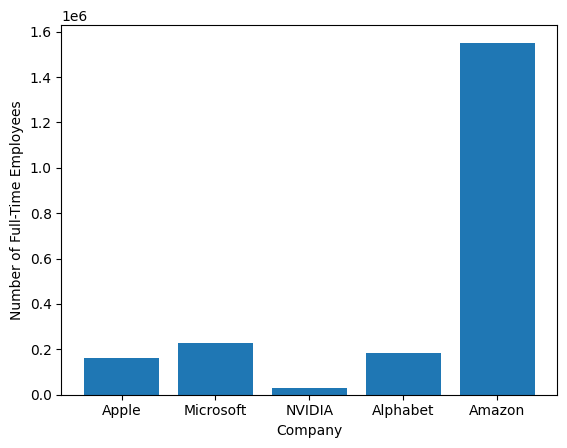

In [ ]:
agent_executor.invoke(
    {
        "input": "Create a plot of the number of full time employees at the 5 tech companies with the highest market cap in the United States in Q3 2024.",
    }
)